In [1]:
# Environment sanity check.

import numpy, pandas, seaborn, matplotlib, numba, shap, xgboost
print(f"numpy   {numpy.__version__}")
print(f"pandas  {pandas.__version__}")
print(f"seaborn {seaborn.__version__}")
print(f"mpl     {matplotlib.__version__}")
print(f"numba   {numba.__version__}")
print(f"shap    {shap.__version__}")
print(f"xgboost {xgboost.__version__}")
assert numpy.__version__.startswith("1."), "NumPy must be <2 — see comment above"

numpy   1.26.4
pandas  2.2.3
seaborn 0.13.2
mpl     3.10.3
numba   0.60.0
shap    0.44.0
xgboost 3.0.0


In [2]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning, module="openpyxl")

import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
import pandas as pd
from pandas.plotting import parallel_coordinates

In [3]:
# Load data
file_path = "HTMDEC_Y2_db.xlsx"
df = pd.read_excel(file_path, sheet_name='Sheet1')

In [4]:
# Select relevant columns
columns_of_interest = [
    "Alloy Name", 'Avg Hdyn (GPa) HSR', 'Avg Hqs (GPa) HSR', "Avg HDYN/HQS", "Yield Strength (MPa)", "UTS_True (Mpa)", 
    "Elong_T (%)", "UTS/YS", "Depth of Penetration (mm) FE_Sim"
]
df_selected = df[columns_of_interest].dropna()

# Restrict to iterations BBA, BBB, BBC
iterations = ["BBA", "BBB", "BBC"]
df_selected = df_selected[df_selected["Alloy Name"].str[:3].isin(iterations)].reset_index(drop=True)

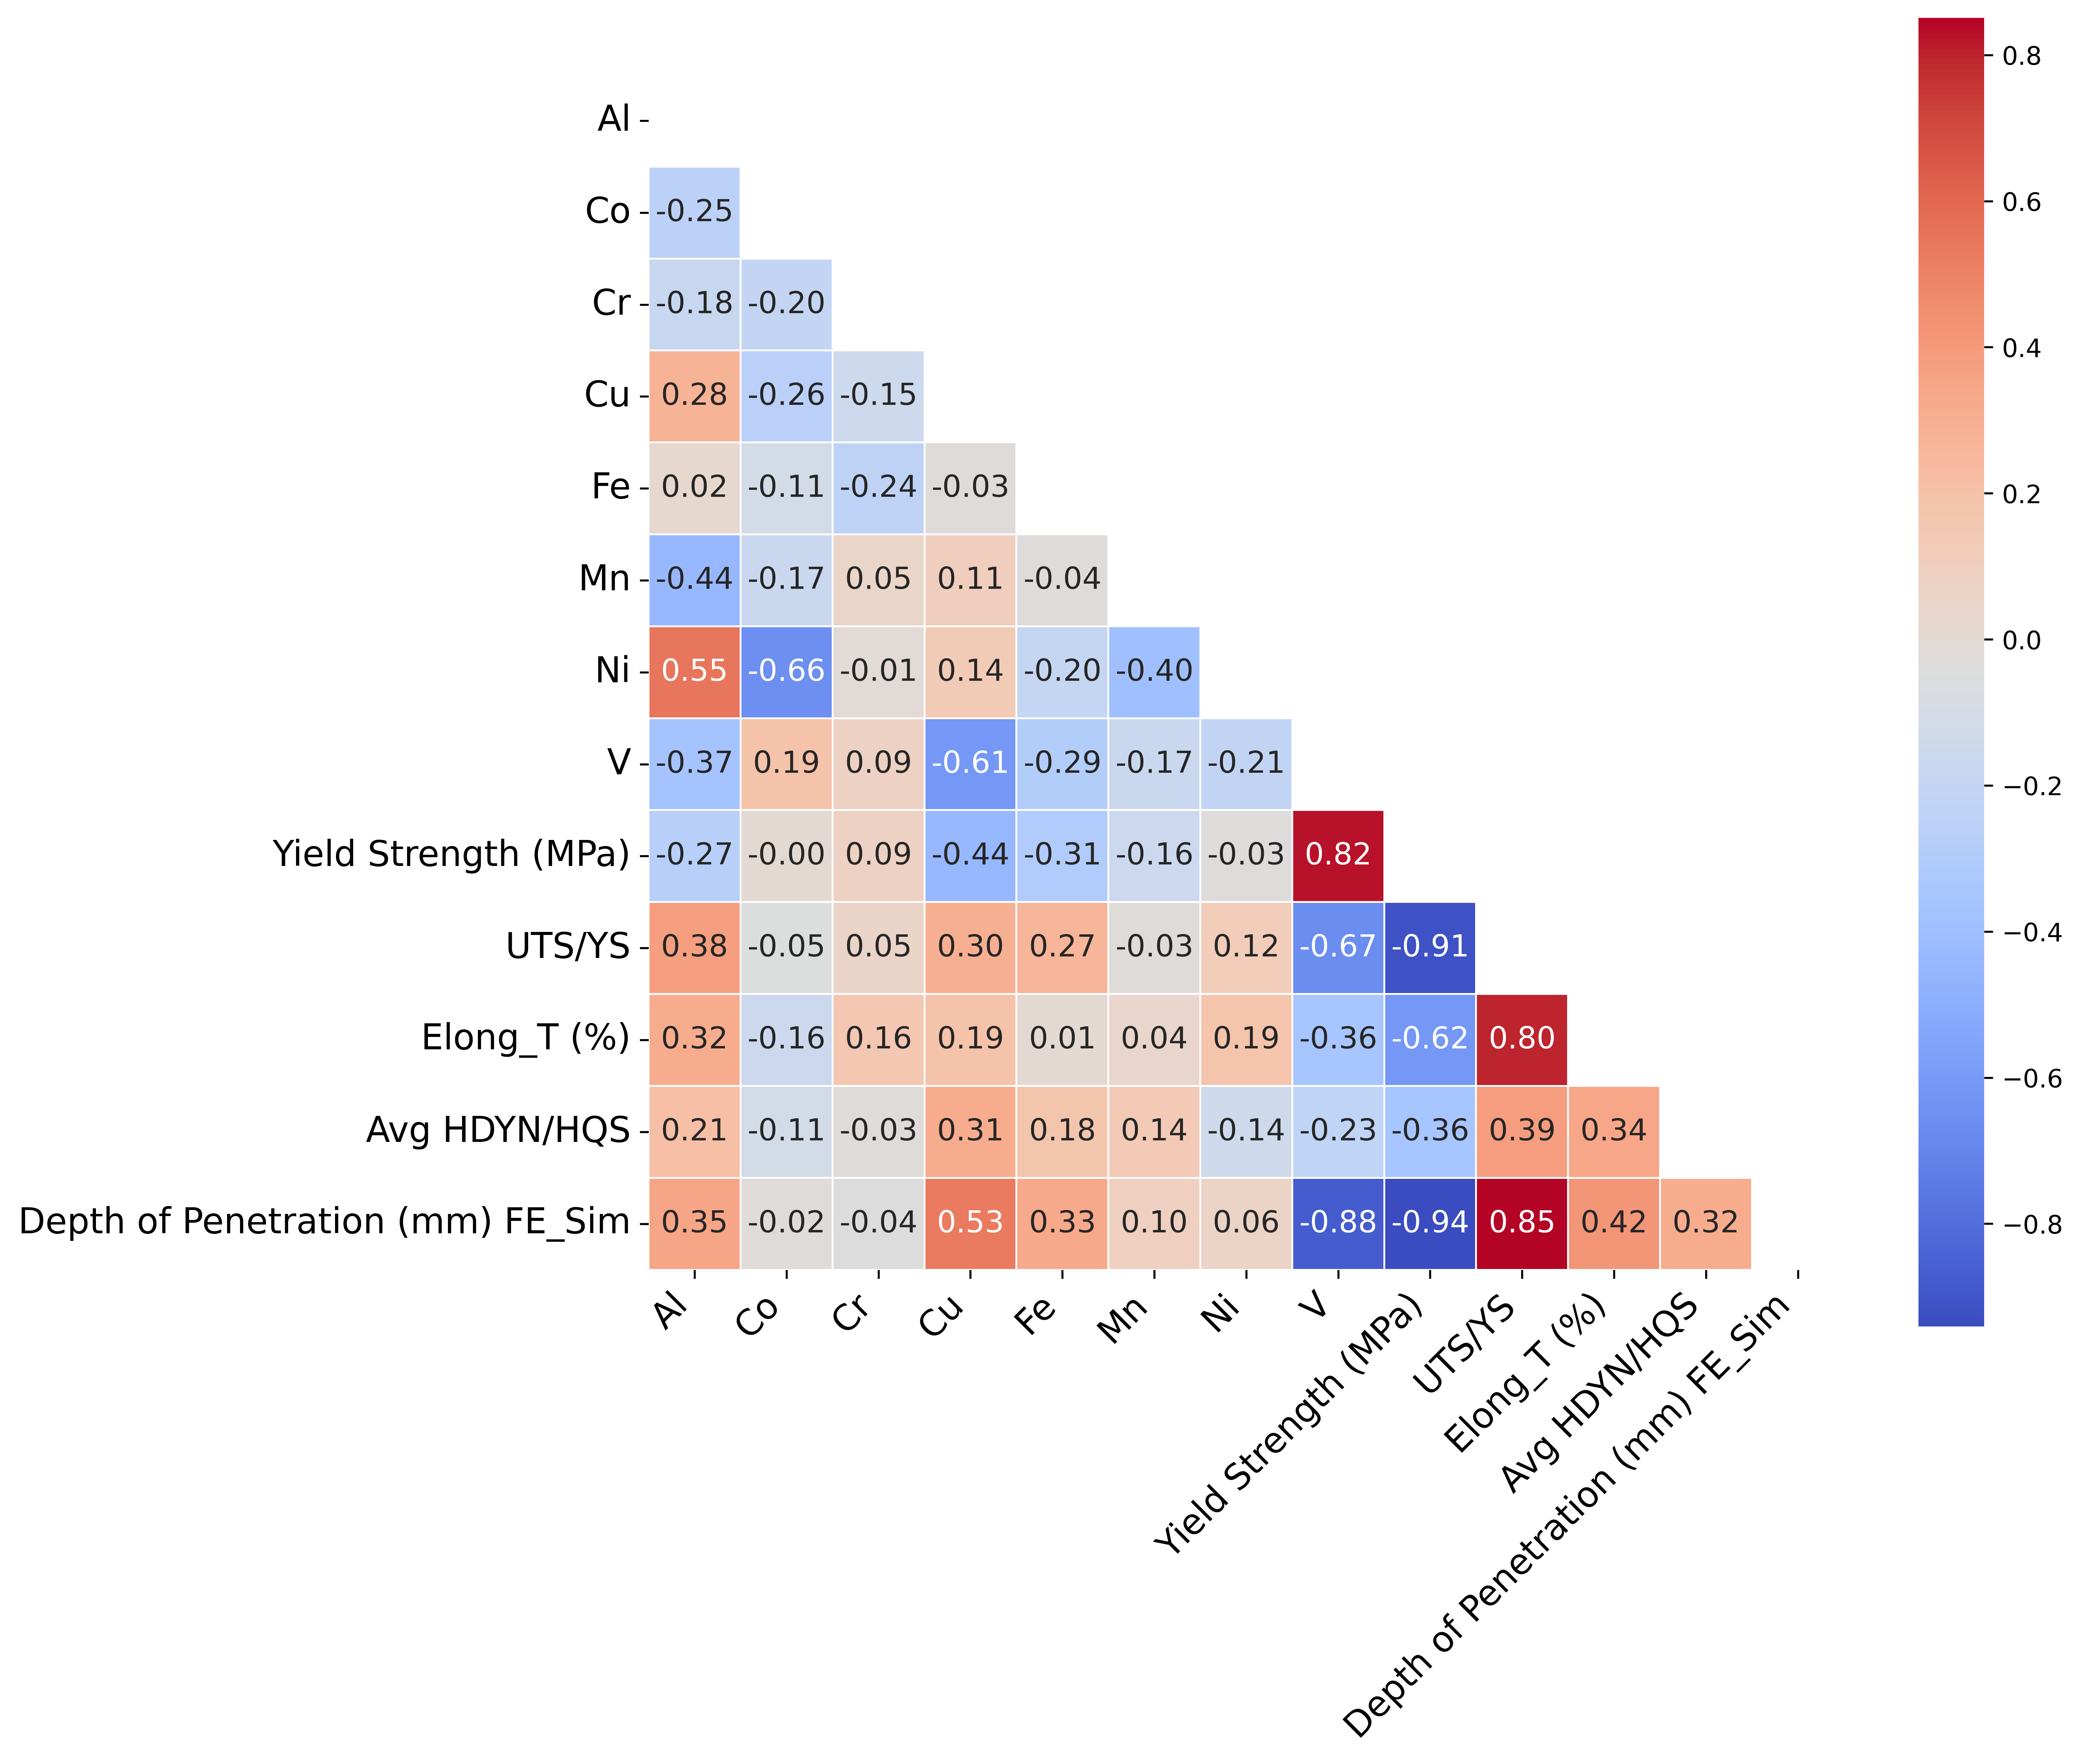

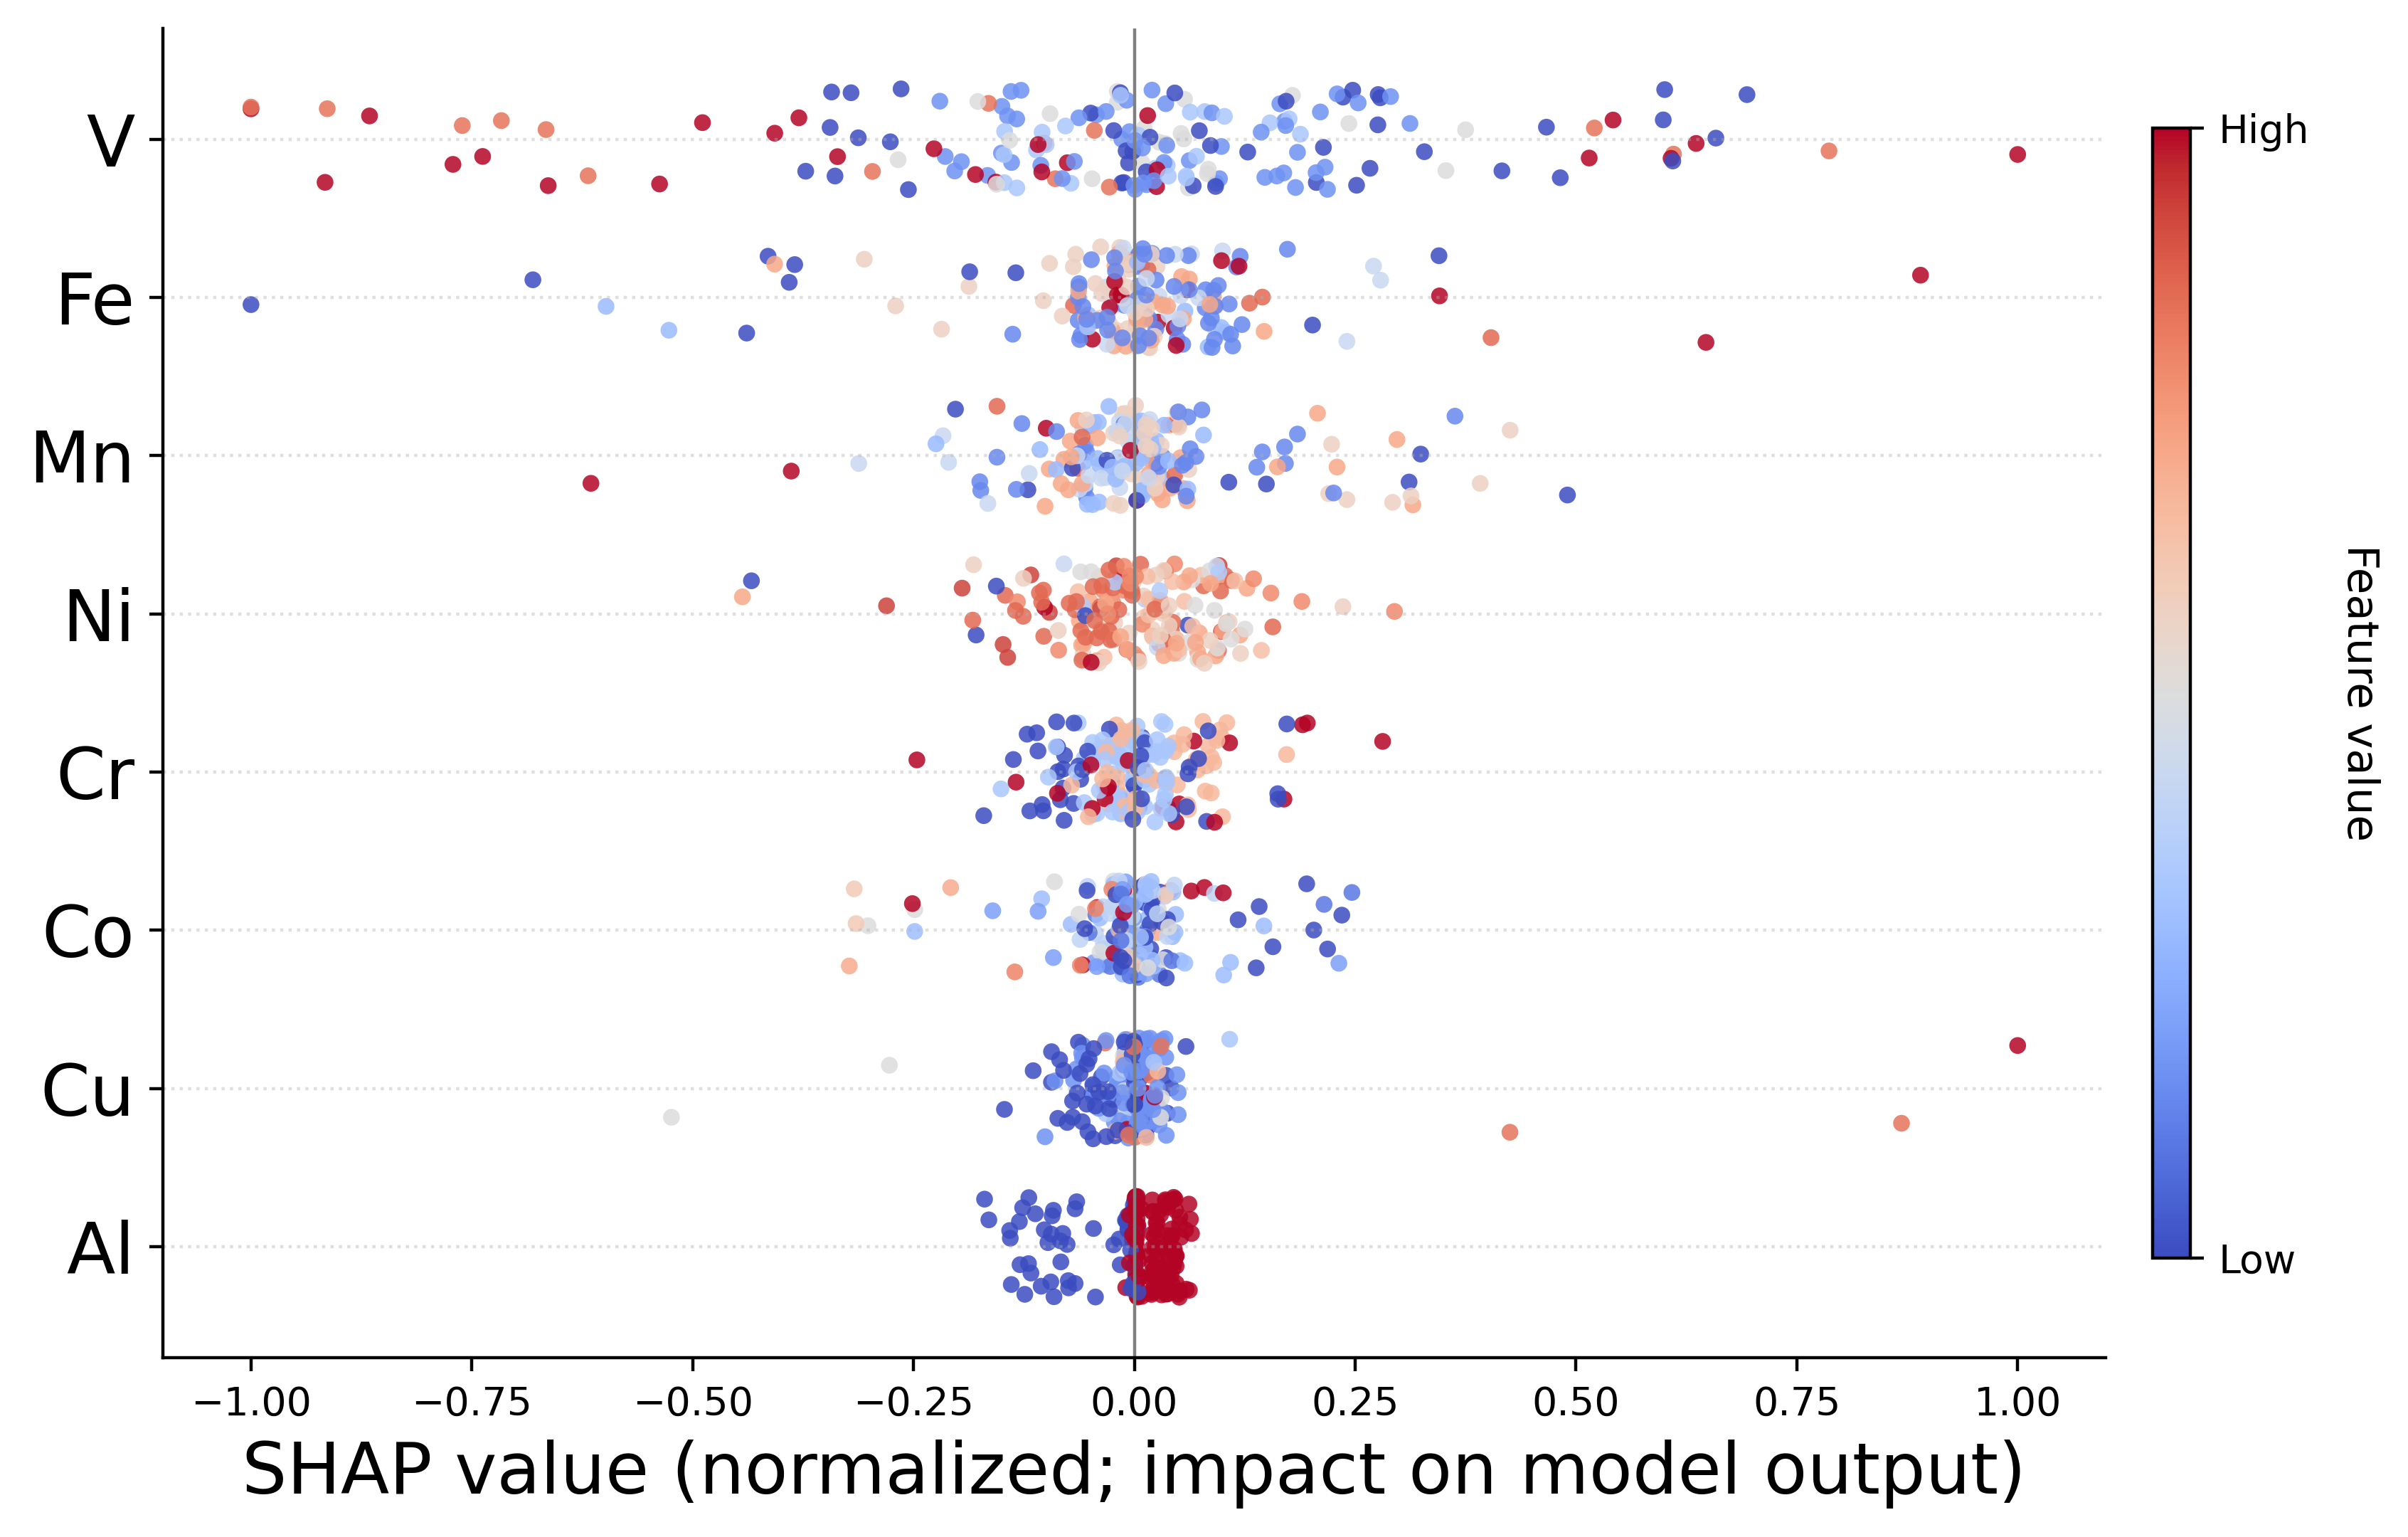

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import shap
from sklearn.ensemble import GradientBoostingRegressor

# ---------- Load ----------
data = pd.read_excel("HTMDEC_Y2_db.xlsx")

# Restrict to iterations BBA, BBB, BBC
iterations = ["BBA", "BBB", "BBC"]
data = data[data["Alloy Name"].str[:3].isin(iterations)].reset_index(drop=True)

features = ['Al', 'Co', 'Cr', 'Cu', 'Fe', 'Mn', 'Ni', 'V']
targets  = ['Yield Strength (MPa)', 'UTS/YS', 'Elong_T (%)',
            'Avg HDYN/HQS', 'Depth of Penetration (mm) FE_Sim']

data = data[features + targets]

# ===================================
# (a) Correlation Heatmap
# ===================================
corr = data.corr()
mask = np.triu(np.ones_like(corr, dtype=bool))

fig, ax = plt.subplots(figsize=(12, 10), dpi=600)
sns.heatmap(
    corr, mask=mask, cmap='coolwarm',
    annot=True, fmt=".2f", linewidths=0.5,
    square=True, cbar_kws={'label': ''},
    annot_kws={"size": 12}, ax=ax,
)
for tick in ax.get_xticklabels():
    tick.set_fontsize(14); tick.set_rotation(45); tick.set_ha('right')
for tick in ax.get_yticklabels():
    tick.set_fontsize(14)
plt.tight_layout()
#plt.savefig("correlation_heatmap.png", dpi=600, bbox_inches='tight')
plt.show()

# ===================================
# (b) Multi-objective SHAP beeswarm — one panel for ALL 5 targets.
# Each target gets its own GBM. SHAP values are normalized per target
# (divided by the per-target max |SHAP|) so all 5 share a comparable
# axis. Then features are sorted by aggregate mean(|normalized SHAP|)
# — that ordering IS the multi-objective elemental importance ranking.
# Each row contains ~37 samples × 5 targets ≈ 185 dots.
# shap_results is reused by the corrSHAP cell below.
# ===================================
shap_results = {}

for target in targets:
    df_t = data[features + [target]].dropna()
    X = df_t[features]
    y = df_t[target]

    model = GradientBoostingRegressor(
        n_estimators=400, max_depth=4, learning_rate=0.05,
        subsample=0.9, random_state=42,
    )
    model.fit(X, y)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X)
    shap_results[target] = {'X': X, 'shap_values': shap_values, 'model': model}

# Pool normalized SHAP values + normalized feature values across all targets.
shap_chunks, fv_chunks, fidx_chunks = [], [], []
for target in targets:
    X = shap_results[target]['X']
    sv = shap_results[target]['shap_values']
    scale = np.max(np.abs(sv))
    sv_norm = sv / scale if scale > 0 else sv
    for i, f in enumerate(features):
        v = X.iloc[:, i].values
        r = v.max() - v.min()
        v_norm = (v - v.min()) / r if r > 0 else np.full_like(v, 0.5, dtype=float)
        shap_chunks.append(sv_norm[:, i])
        fv_chunks.append(v_norm)
        fidx_chunks.append(np.full(len(v), i))
shap_all = np.concatenate(shap_chunks)
fv_all   = np.concatenate(fv_chunks)
fidx_all = np.concatenate(fidx_chunks)

imp = np.array([np.mean(np.abs(shap_all[fidx_all == i])) for i in range(len(features))])
order = np.argsort(imp)[::-1]  # most important at top

fig, ax = plt.subplots(figsize=(9, 5.5), dpi=400)
rng = np.random.default_rng(0)
for y_pos, fi in enumerate(order):
    mask = fidx_all == fi
    s = shap_all[mask]; fv = fv_all[mask]
    y_jit = rng.uniform(-0.32, 0.32, len(s))
    ax.scatter(s, np.full_like(s, y_pos, dtype=float) + y_jit,
               c=fv, cmap='coolwarm', vmin=0, vmax=1,
               s=18, alpha=0.85, edgecolor='none')

ax.set_yticks(range(len(features)))
ax.set_yticklabels([features[i] for i in order], fontsize=18)
ax.invert_yaxis()
ax.axvline(0, color='gray', linewidth=0.8)
ax.set_xlabel('SHAP value (normalized; impact on model output)', fontsize=18)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
ax.grid(axis='y', linestyle=':', alpha=0.4)

sm = plt.cm.ScalarMappable(cmap='coolwarm', norm=plt.Normalize(vmin=0, vmax=1))
sm.set_array([])
cbar = fig.colorbar(sm, ax=ax, shrink=0.85, pad=0.02, aspect=30)
cbar.set_label('Feature value', fontsize=11, rotation=270, labelpad=18)
cbar.set_ticks([0, 1]); cbar.set_ticklabels(['Low', 'High'])
cbar.ax.tick_params(labelsize=10)

plt.tight_layout()
#plt.savefig("shap_multiobjective.png", dpi=600, bbox_inches='tight')
plt.show()

Multi-objective corrSHAP (mean across 5 targets):
Al    0.794
Fe    0.262
Cr    0.222
Cu    0.149
Ni    0.020
Mn   -0.156
Co   -0.194
V    -0.339


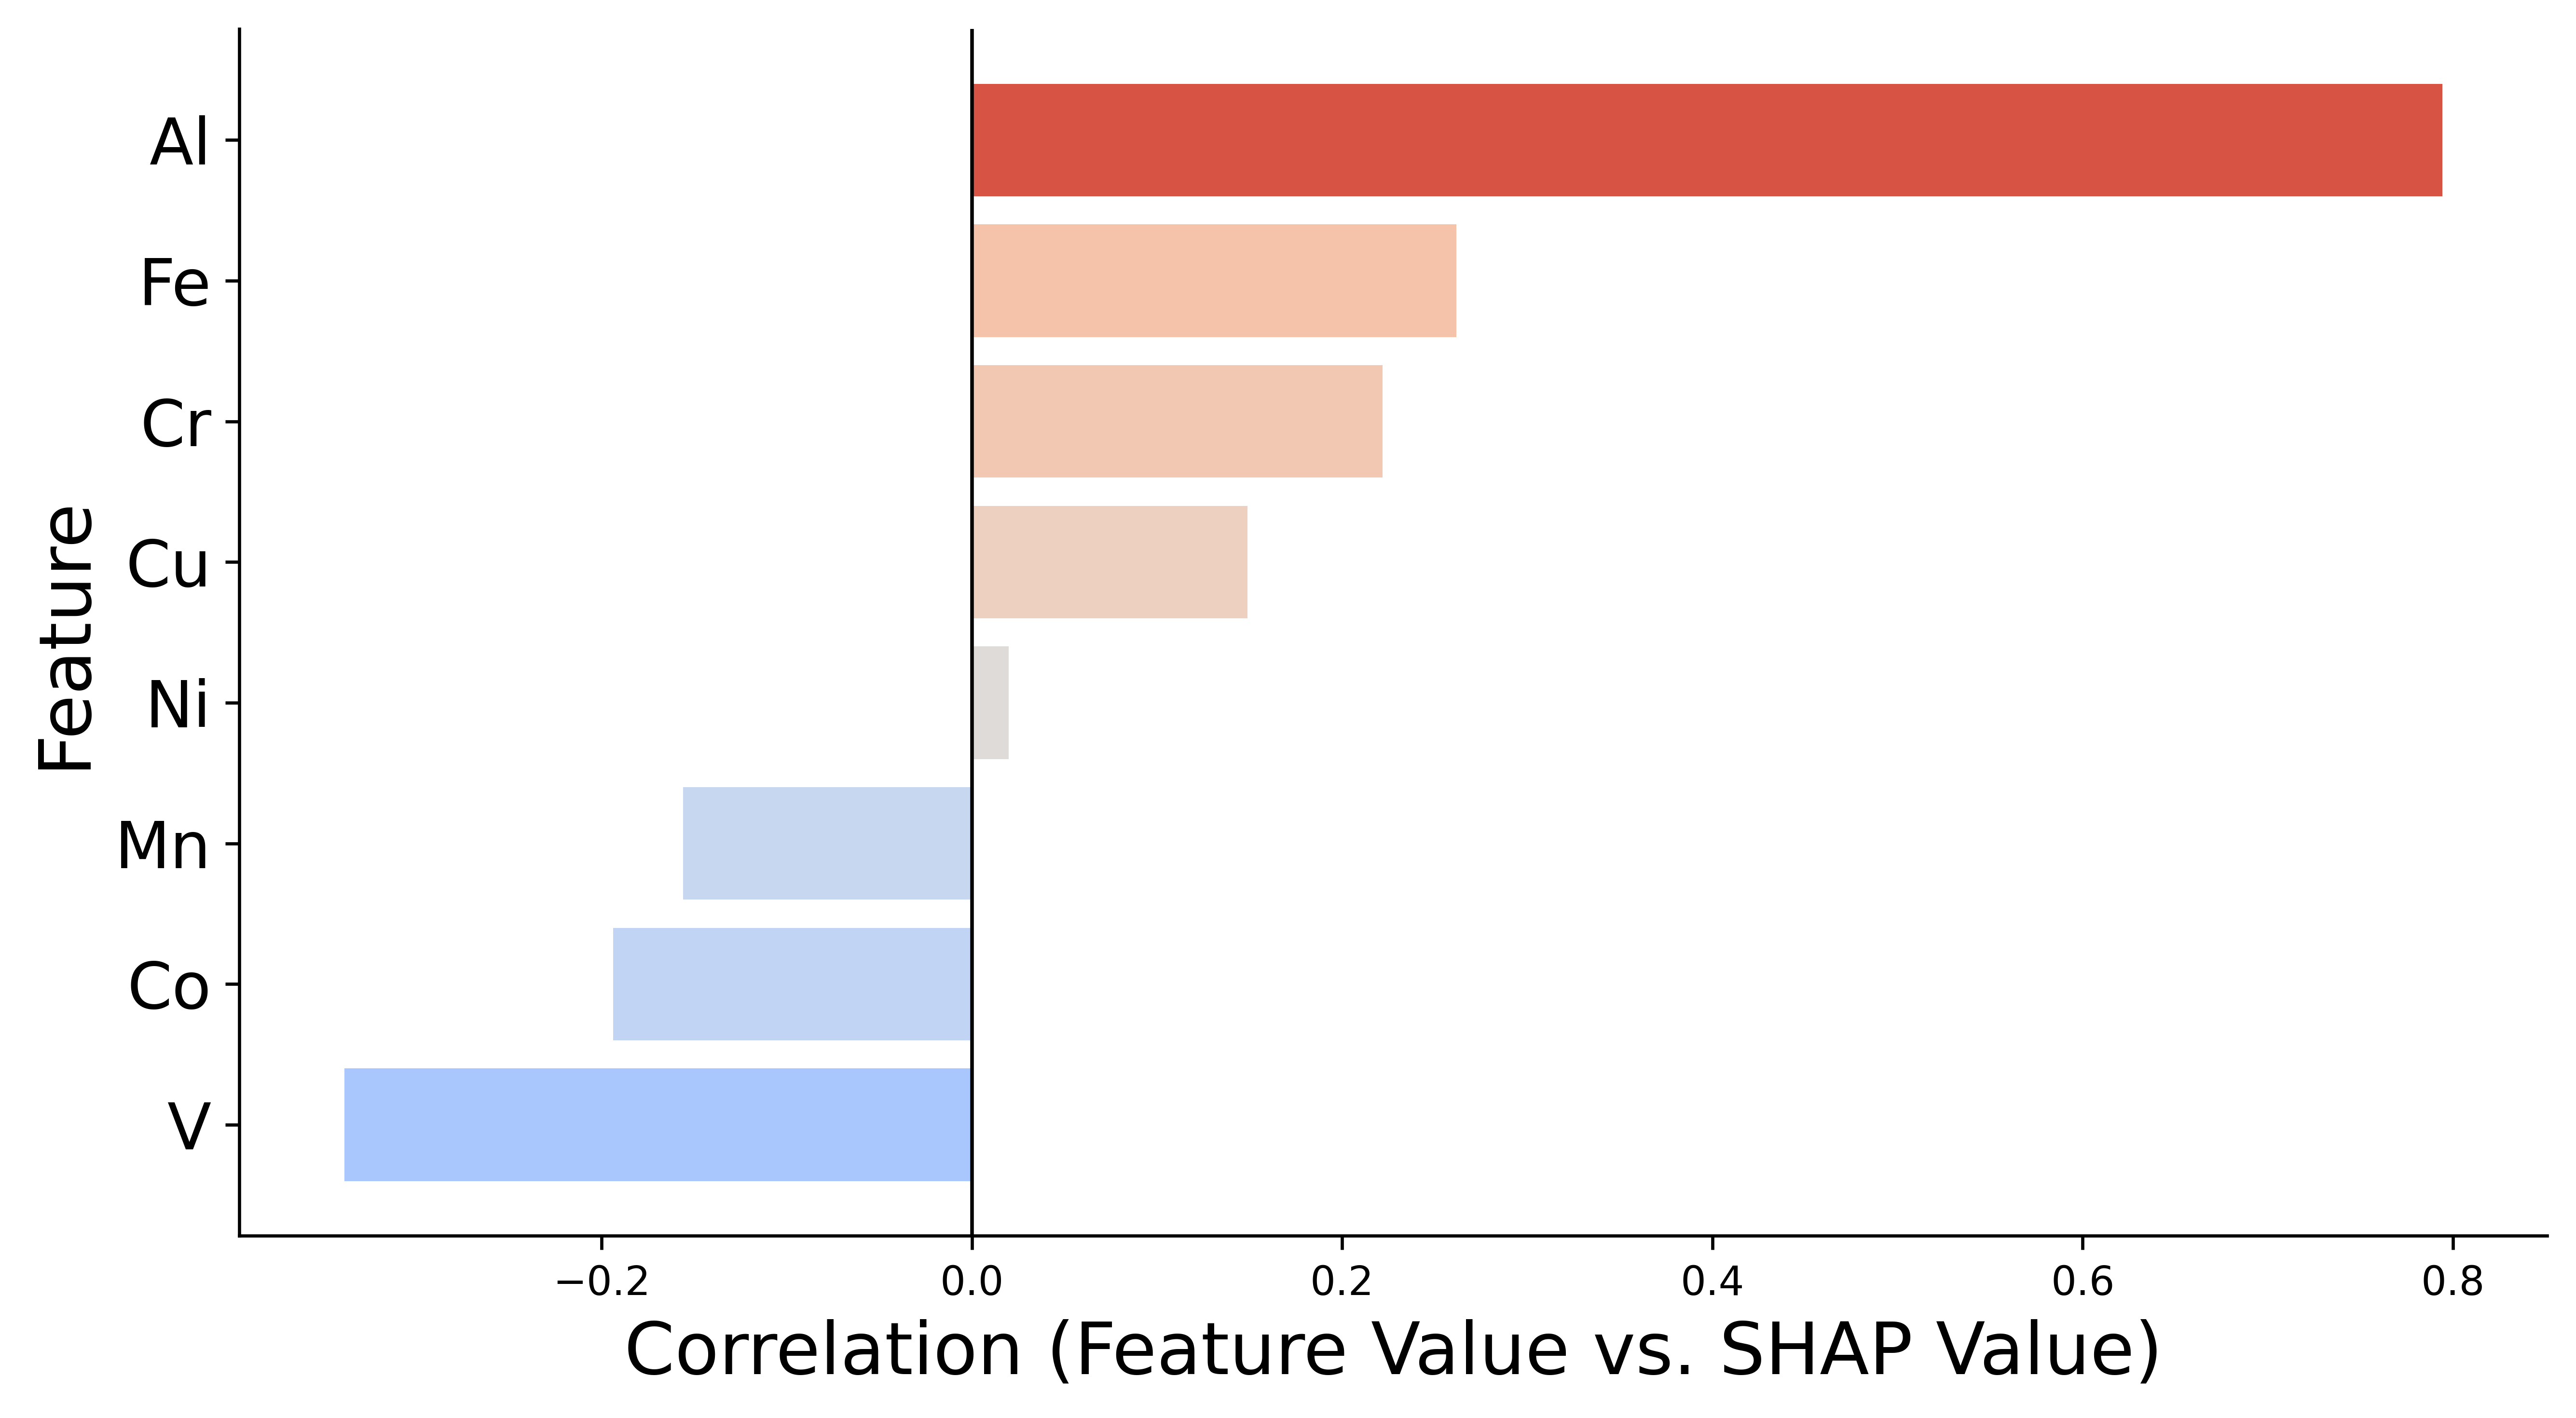

In [6]:
# ===================================
# Multi-objective corrSHAP — one bar plot for ALL 5 targets.
# Compute corrSHAP per (target, feature) first, then average across the
# 5 targets to get one signed value per element. Positive = high values
# of this element tend to push the multi-objective response up; negative
# = push it down. Cancellation across targets is the correct multi-
# objective tradeoff signal.
# ===================================

corrshap_table = {}
for target, bundle in shap_results.items():
    X = bundle['X']
    sv = bundle['shap_values']
    corrshap_table[target] = {
        f: (np.corrcoef(X[f], sv[:, i])[0, 1]
            if np.std(X[f]) > 0 and np.std(sv[:, i]) > 0 else np.nan)
        for i, f in enumerate(features)
    }
corrshap_df = pd.DataFrame(corrshap_table)             # rows=features, cols=targets
multi_corrshap = corrshap_df.mean(axis=1).sort_values(ascending=False)

print("Multi-objective corrSHAP (mean across 5 targets):")
print(multi_corrshap.round(3).to_string())

fig, ax = plt.subplots(figsize=(9, 5), dpi=600)
cmap = plt.get_cmap('coolwarm')
norm = plt.Normalize(vmin=-1, vmax=1)
ax.barh(multi_corrshap.index, multi_corrshap.values,
        color=cmap(norm(multi_corrshap.values)), edgecolor='none')
ax.invert_yaxis()
ax.axvline(0, color='black', linewidth=0.9)
ax.set_xlabel('Correlation (Feature Value vs. SHAP Value)', fontsize=18)
ax.set_ylabel('Feature', fontsize=18)
ax.tick_params(axis='y', labelsize=16)
ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
#plt.savefig("corrSHAP_multiobjective.png", dpi=600, bbox_inches='tight')
plt.show()

In [7]:
# Create Group column
if 'Alloy Name' in df_selected:
    df_selected["Group"] = df_selected["Alloy Name"].str[:3].astype(str)

# Define color mapping
color_mapping = {"BBA": "#E69F00", "BBB": "#56B4E9", "BBC": "#009E73"}
df_selected["Color"] = df_selected["Group"].map(color_mapping)

# Drop 'Alloy Name' from numeric dataframe
df_raw = df_selected.drop(columns=["Alloy Name", "Color"]).apply(pd.to_numeric, errors='coerce').dropna()

# Convert Group column to string explicitly
df_raw["Group"] = df_selected["Group"].astype(str)


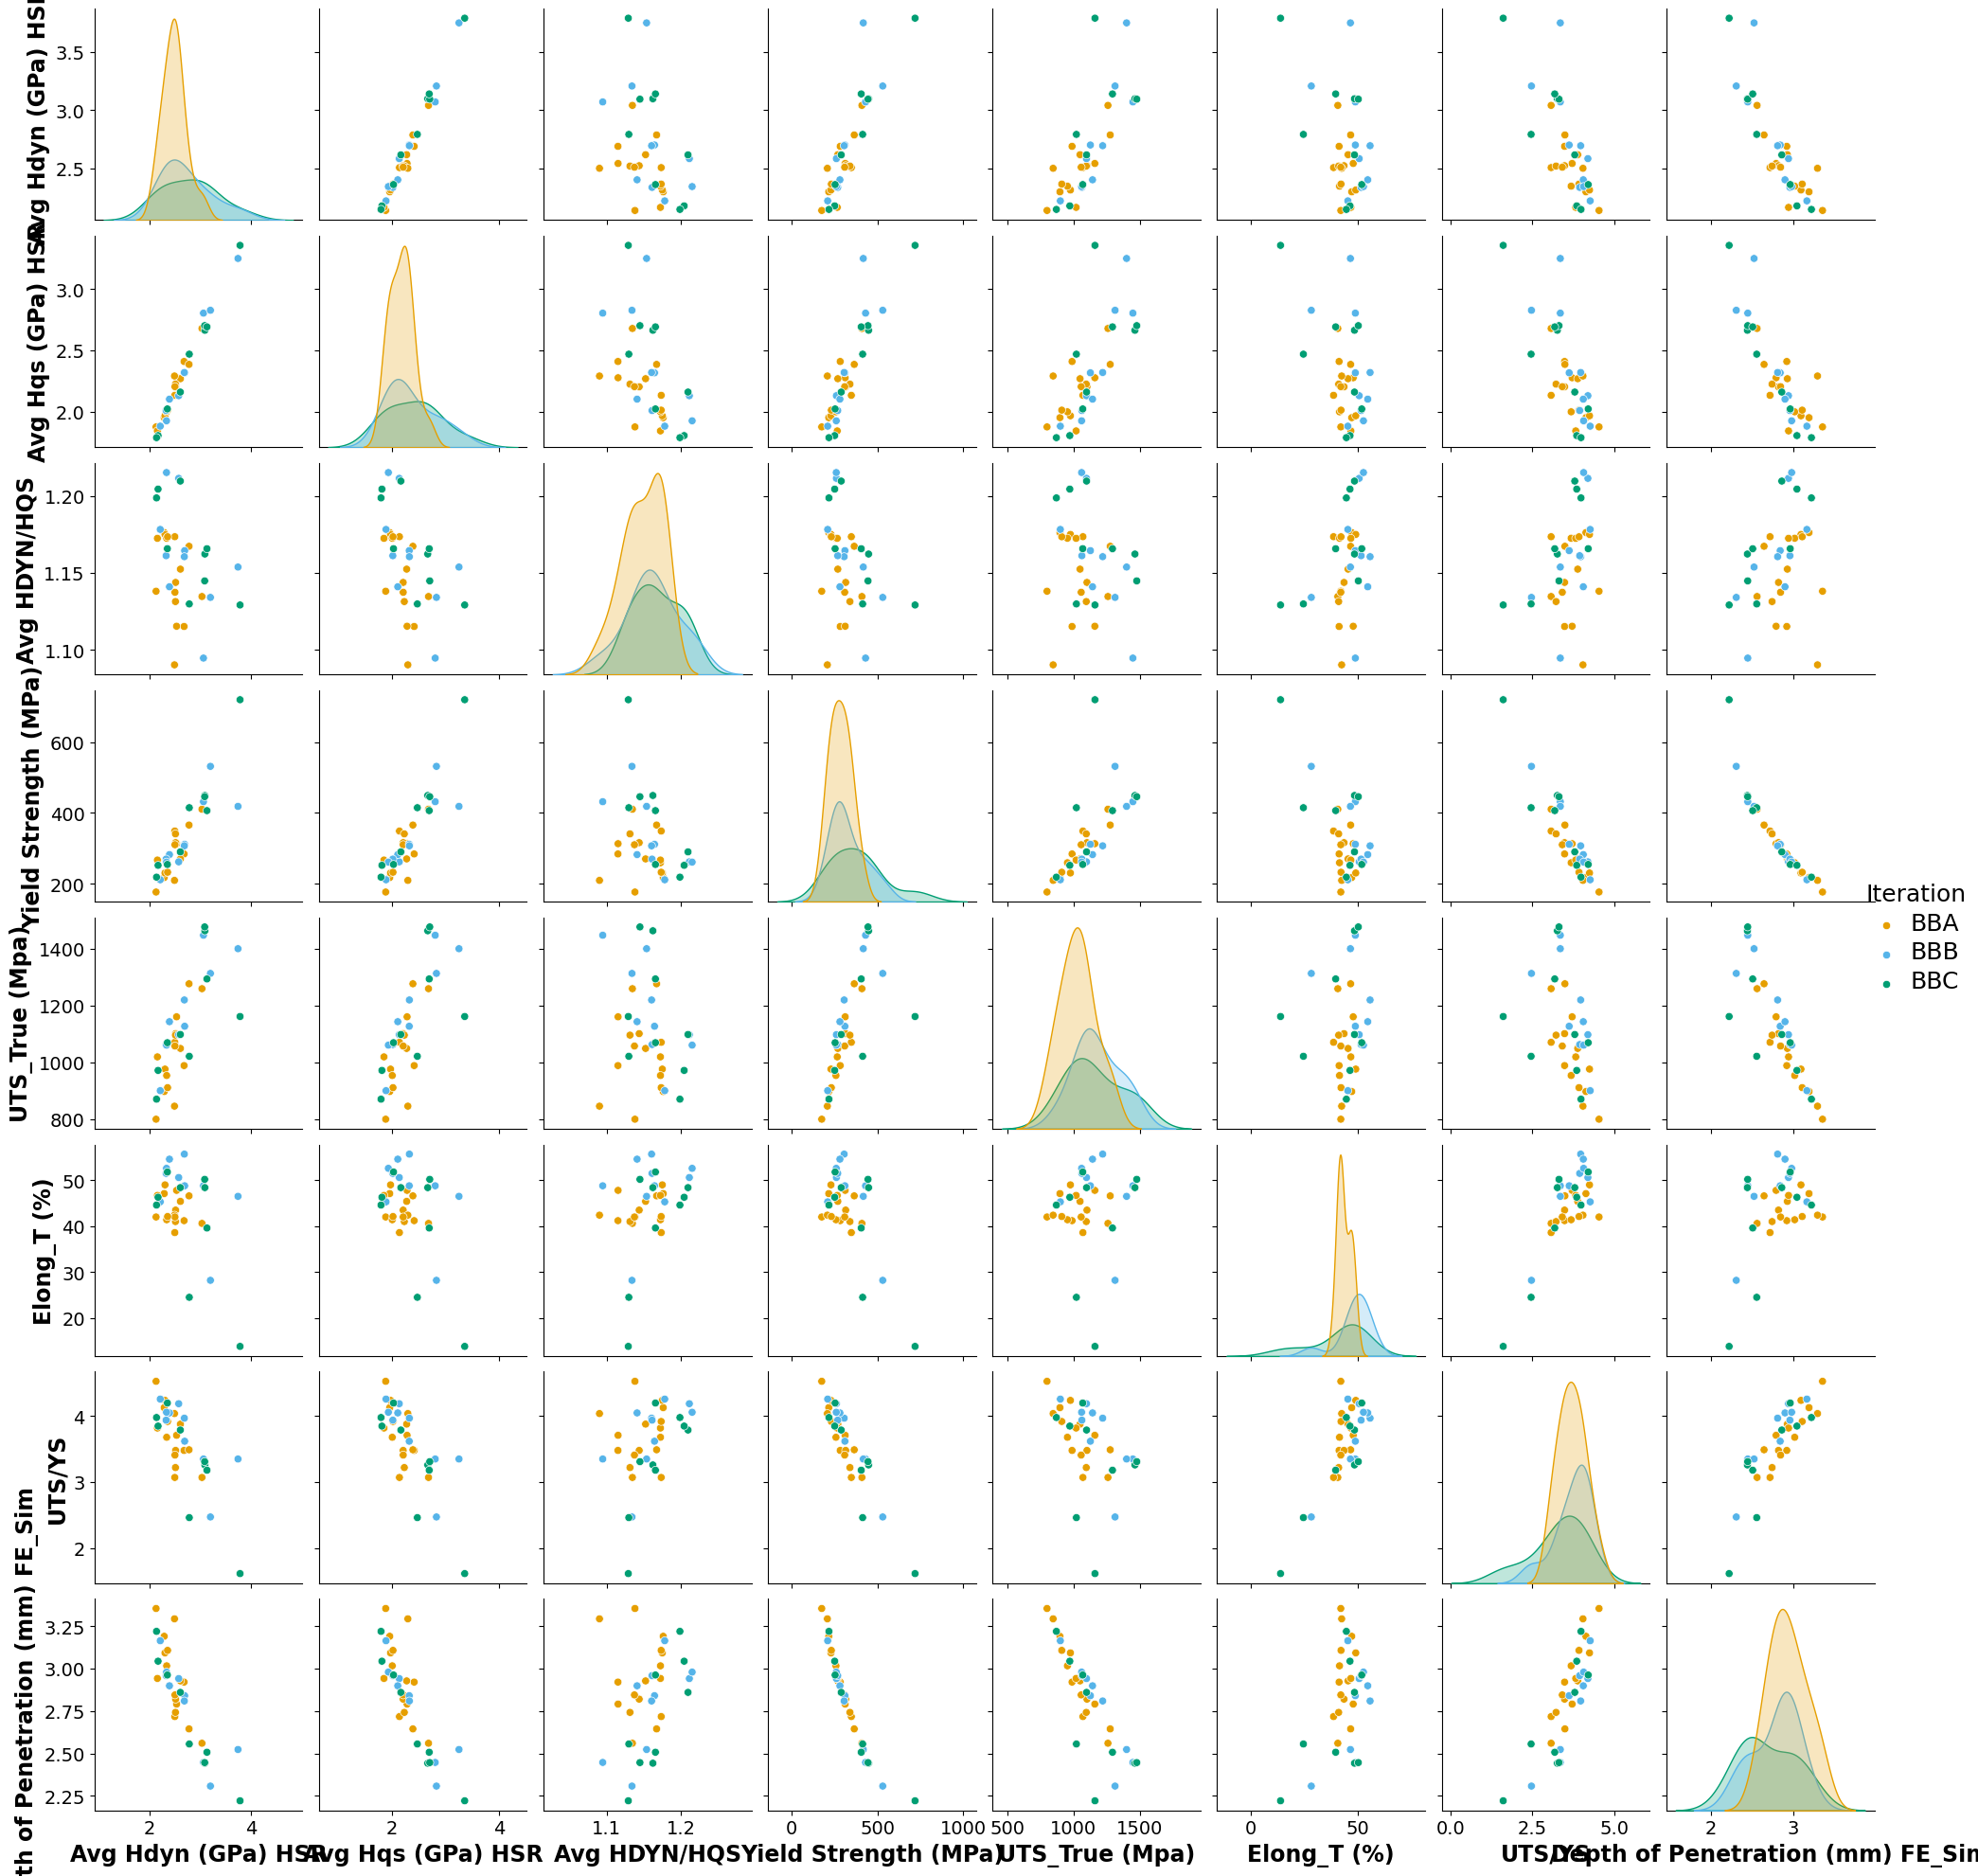

In [8]:
#3 Property Pair Plot

import seaborn as sns
import matplotlib.pyplot as plt

# Create the pairplot
pairplot = sns.pairplot(df_selected, hue="Group", diag_kind="kde", palette=color_mapping)

# Adjust font sizes for axis labels and tick labels
for ax in pairplot.axes.flatten():
    if ax is not None:
        ax.set_xlabel(ax.get_xlabel(), fontsize=17, fontweight='bold')
        ax.set_ylabel(ax.get_ylabel(), fontsize=17, fontweight='bold')
        ax.tick_params(axis='both', labelsize=14)

# Adjust title and legend font sizes
legend = pairplot._legend
legend.set_title("Iteration")
legend.get_title().set_fontsize(18)  # Set legend title font size

for text in legend.get_texts():
    text.set_fontsize(18)  # Set legend item font size


# Show and save
plt.show()
#pairplot.fig.savefig('Property_Pair_Plot.png', dpi=600, bbox_inches='tight')


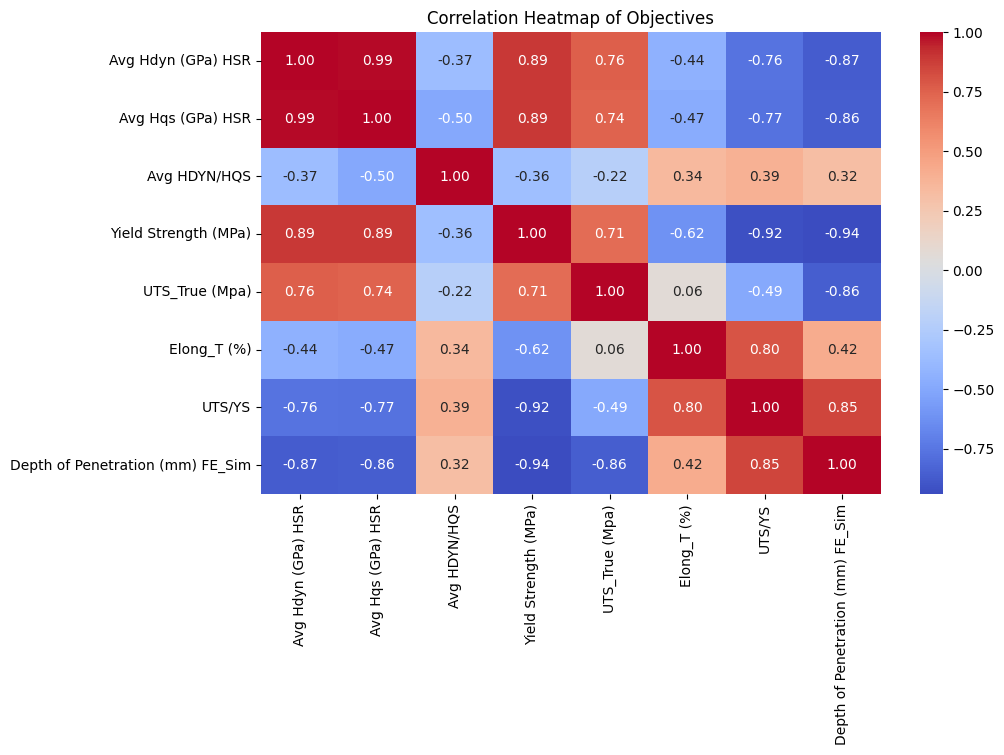

In [9]:
# 4. Heatmap (Correlation Matrix)
plt.figure(figsize=(10, 6))
heatmap = sns.heatmap(df_selected.drop(columns=["Alloy Name", "Group", "Color"]).corr(), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Correlation Heatmap of Objectives")
plt.show()
#heatmap.figure.savefig('heatmap.png', dpi=600, bbox_inches='tight')




Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.



Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same e

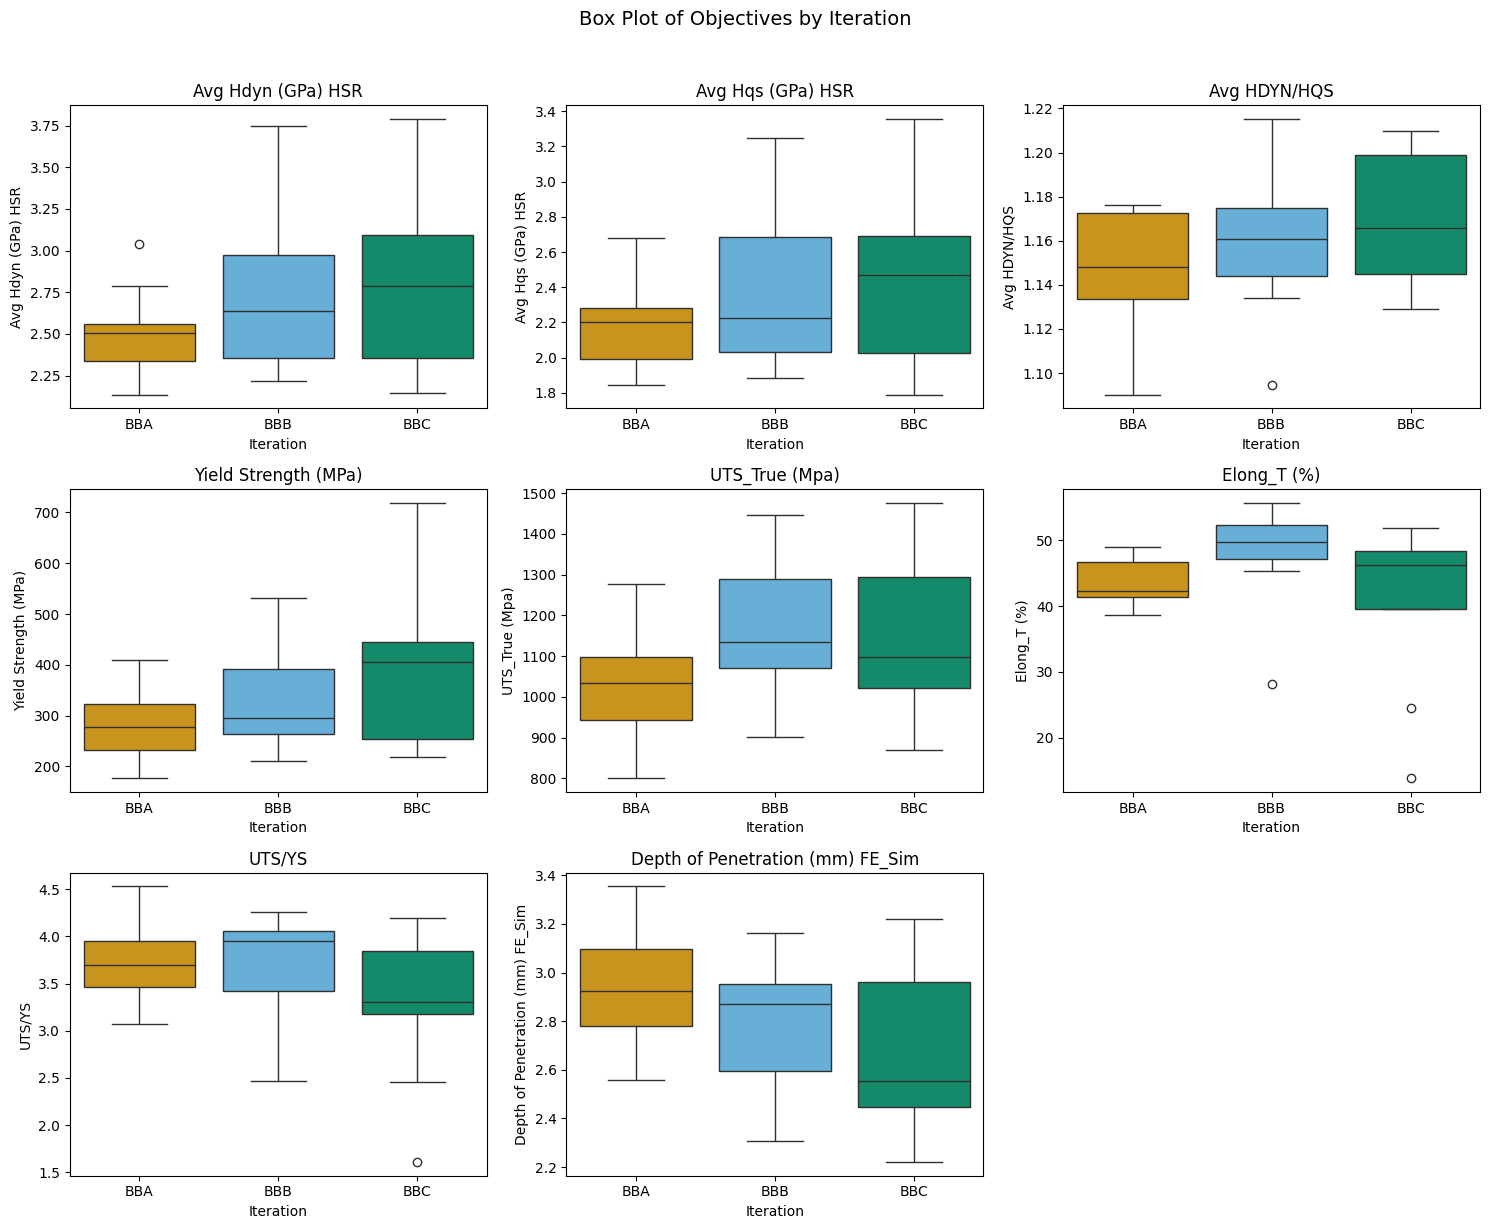

In [10]:
# 5. Box Plot for Distribution Analysis — one subplot per property
properties = [c for c in df_selected.columns if c not in ("Alloy Name", "Group", "Color")]

n = len(properties)
ncols = 3
nrows = int(np.ceil(n / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(5 * ncols, 4 * nrows))
axes = np.array(axes).reshape(-1)

for ax, prop in zip(axes, properties):
    sns.boxplot(x="Group", y=prop, data=df_selected, palette=color_mapping, ax=ax)
    ax.set_title(prop)
    ax.set_xlabel("Iteration")
    ax.set_ylabel(prop)

for ax in axes[n:]:
    ax.axis("off")

fig.suptitle("Box Plot of Objectives by Iteration", y=1.02, fontsize=14)
plt.tight_layout()
#plt.savefig("boxplots_per_property.png", dpi=600, bbox_inches="tight")
plt.show()